In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# !git clone https://github.com/VSmague/Dynamical-Variational-Autoencoders.git

In [3]:
import os
# os.chdir("Dynamical-Variational-Autoencoders")

In [4]:
# !git checkout jlnew

In [5]:
# import sys
# sys.path.append('.')
# print("Current directory added to sys.path.")

# Notebook.ipynb content

# Imports

In [6]:
# pip install librosa

In [7]:
# pip install matplotlib

In [8]:

import os
import sys
# os.chdir("..")
sys.path.append(os.path.abspath(".."))

import json
import torch
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt
import torchaudio
import glob

from model.VRNN import VRNN
from model.SRNN import SRNN
from dataset.audio_dataset import AudioDataset
from utils.padding import collate_fn
from experiments.train import train, evaluate

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [10]:
model = SRNN(x_dim=80).to(device)

On repasse à la branche main pour récupérer les données du dataset.

In [11]:
# !git checkout main

In [12]:
#pour colab 
# data_dirs = [
#     "/content/Dynamical-Variational-Autoencoders/data/mels_saved/part_0",
#     "/content/Dynamical-Variational-Autoencoders/data/mels_saved/part_1",
#     "/content/Dynamical-Variational-Autoencoders/data/mels_saved/part_2"
# ]


#pour sspcloud: 
data_dirs = [
"../data/mels_saved/part_0",
"../data/mels_saved/part_1",
"../data/mels_saved/part_2"
]

# Initialize AudioDataset for each part and concatenate them
full_dataset = torch.utils.data.ConcatDataset([
    AudioDataset(data_dir) for data_dir in data_dirs
])


all_mels = []
for i in range(len(full_dataset)):
    all_mels.append(full_dataset[i])

all_mels_tensor = torch.cat(all_mels, dim=0)

mean_full = all_mels_tensor.mean()
std_full = all_mels_tensor.std()
print("les données sont déja normalisées attention: ", mean_full,std_full)

les données sont déja normalisées attention:  tensor(0.1542) tensor(0.9692)


In [13]:
N = len(full_dataset)
train_len = int(0.8 * N)
val_len = int(0.1 * N)
test_len = N - train_len - val_len

print(f"Dataset split: Train {train_len}, Validation {val_len}, Test {test_len} samples.")

g = torch.Generator().manual_seed(42)

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_len, val_len, test_len],
    generator=g
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)



Dataset split: Train 2337, Validation 292, Test 293 samples.


Type du batch: <class 'torch.Tensor'>
Shape du batch: torch.Size([200, 32, 80])
Shape séquence 0 : torch.Size([200, 80])
tensor([[-0.4890, -1.1509, -0.6494,  ...,  0.7986,  0.4431, -0.0084],
        [-0.2106, -0.4187, -0.6043,  ...,  1.0698,  0.7225,  0.2626],
        [ 0.0242, -1.1584, -0.7298,  ...,  0.5569,  0.2247, -0.1905],
        ...,
        [ 0.5227,  0.9635,  0.1236,  ..., -0.9858, -1.1599, -1.1080],
        [ 0.6486,  0.4926,  0.1029,  ..., -1.0207, -1.1504, -1.0479],
        [ 0.0735, -1.6121, -0.6111,  ..., -1.0228, -1.0588, -1.1083]])


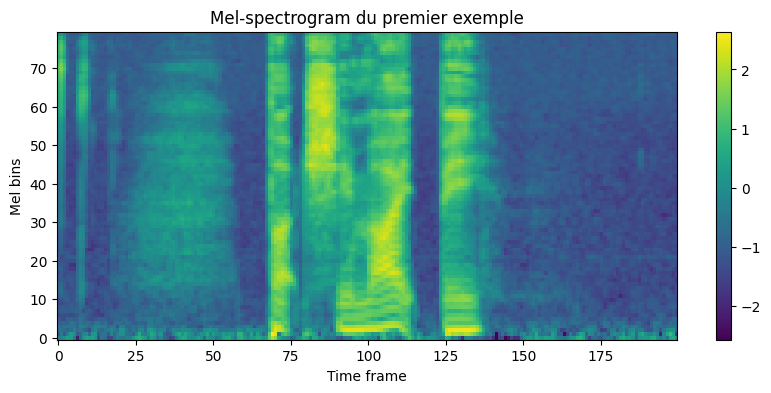

In [14]:
# Récupère le premier batch
batch = next(iter(train_loader))
print("Type du batch:", type(batch))
print("Shape du batch:", batch.shape)

x0 = batch[:, 0, :]   # shape = (seq_len, mel_dim)
print("Shape séquence 0 :", x0.shape)
print(x0)

plt.figure(figsize=(10,4))
plt.imshow(x0.T, aspect="auto", origin="lower")
plt.colorbar()
plt.title("Mel-spectrogram du premier exemple")
plt.xlabel("Time frame")
plt.ylabel("Mel bins")
plt.show()

In [15]:
import os
import sys
# os.chdir("..")
sys.path.append(os.path.abspath(".."))

import json
import torch
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt
import torchaudio
import glob
from tqdm import tqdm # Import tqdm

from model.SRNN import SRNN
from dataset.audio_dataset import AudioDataset
from utils.padding import collate_fn
from experiments.train import train, evaluate



import os
import json
import torch


def save_checkpoint(state, checkpoint_dir, name="last.pt"):
    os.makedirs(checkpoint_dir, exist_ok=True)
    path = os.path.join(checkpoint_dir, name)
    torch.save(state, path)


def load_checkpoint(model, optimizer, checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    start_epoch = checkpoint["epoch"] + 1
    history = checkpoint["history"]
    print(f"Checkpoint loaded from: {checkpoint_path}")
    return start_epoch, history


def evaluate(model, dataloader, device):
    model.eval()
    total_recon, total_kld = 0, 0
    n_batches = 0

    with torch.no_grad():
        for batch in dataloader:
            batch = batch.to(device)              # (batch, seq, feat)
            batch = batch.permute(1, 0, 2)        # → (seq, batch, feat)
            seq_len, batch_size, _ = batch.shape

            _,recon, kld = model(batch)
            recon = recon / (batch_size * seq_len)
            kld = kld / (batch_size * seq_len)

            total_recon += recon.item()
            total_kld += kld.item()
            n_batches += 1

    return total_recon / n_batches, total_kld / n_batches



def train_model(
    model,
    train_loader,
    val_loader,
    checkpoint_dir="checkpoints",
    resume=False,
    epochs=50,
    batch_size=32,
    lr=1e-4,
    kl_anneal_epochs=10,
    patience=7,
    device="cuda"
):

    device = torch.device(device if torch.cuda.is_available() else "cpu")
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Tracking
    history = {
        "train": [],
        "val": [],
        "beta": [],
        "train_recon": [],
        "train_kld": [],
        "val_recon": [],
        "val_kld": []
    }

    start_epoch = 0
    best_val_loss = float("inf")
    patience_counter = 0

    # Resume training
    last_ckpt = os.path.join(checkpoint_dir, "last.pt")
    if resume and os.path.exists(last_ckpt):
        start_epoch, history = load_checkpoint(model, optimizer, last_ckpt, device)
        print(f"Resuming from epoch {start_epoch}")

    # Training loop
    for epoch in range(start_epoch, epochs):
        model.train()
        total_recon, total_kld = 0, 0
        n_batches = 0

        beta = min(1.0, epoch / kl_anneal_epochs)

        # Wrap train_loader with tqdm for a progress bar
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training"): # Added tqdm here
            batch = batch.to(device)             # (batch, seq, feat)
            batch = batch.permute(1, 0, 2)       # → (seq, batch, feat)
            seq_len, batch_size, _ = batch.shape

            optimizer.zero_grad()
            _, recon, kld = model(batch)

            recon = recon / (batch_size * seq_len)
            kld = kld / (batch_size * seq_len)
            loss = recon + beta * kld

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_recon += recon.item()
            total_kld += kld.item()
            n_batches += 1

        train_recon = total_recon / n_batches
        train_kld = total_kld / n_batches
        train_loss = train_recon + beta * train_kld

        # Validation
        val_recon, val_kld = evaluate(model, val_loader, device=device)
        val_loss = val_recon + beta * val_kld

        print(f"[{epoch+1}/{epochs}] "
              f"Train: {train_loss:.3f} | Val: {val_loss:.3f} | β={beta:.3f}")

        # Update history
        history["train"].append(train_loss)
        history["val"].append(val_loss)
        history["beta"].append(beta)
        history["train_recon"].append(train_recon)
        history["train_kld"].append(train_kld)
        history["val_recon"].append(val_recon)
        history["val_kld"].append(val_kld)

        # Save last checkpoint
        save_checkpoint({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "history": history
        }, checkpoint_dir, "last.pt")

        # Save best model
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            save_checkpoint({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "history": history
            }, checkpoint_dir, "best.pt")
            patience_counter = 0
            print(" → Saved BEST model")
        else:
            patience_counter += 1

        # Early stopping
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    # Save history as JSON
    with open(os.path.join(checkpoint_dir, "history.json"), "w") as f:
        json.dump(history, f, indent=4)

    print("\nTraining complete.")
    return history



Interpretation: from epoch 10 to 40, the models does not exploit the latent vector z and only relies on the RNN part: this results in a posterior q(z I x) that remains identical to the prior p(z) and a null KL. However, after epoch 40, the model starts using the latent variable z: this results in a decreasing loss but an increase in the KL as q(z I x) changes.

We need to increase the number of epochs and the rate at which parameter beta increases to avoid this phenomenon.

In [16]:
model = SRNN(x_dim=80).to(device)

Epoch 1/150 Training: 100%|██████████| 74/74 [00:04<00:00, 15.37it/s]


[1/150] Train: -48.812 | Val: -51.711 | β=0.000
 → Saved BEST model


Epoch 2/150 Training: 100%|██████████| 74/74 [00:04<00:00, 16.47it/s]


[2/150] Train: -50.822 | Val: -51.330 | β=0.033


Epoch 3/150 Training: 100%|██████████| 74/74 [00:04<00:00, 17.78it/s]


...

[148/150] Train: -64.726 | Val: -64.863 | β=1.000
 → Saved BEST model


Epoch 149/150 Training: 100%|██████████| 74/74 [00:03<00:00, 19.25it/s]


[149/150] Train: -65.038 | Val: -64.894 | β=1.000
 → Saved BEST model


Epoch 150/150 Training: 100%|██████████| 74/74 [00:03<00:00, 18.58it/s]


[150/150] Train: -64.762 | Val: -64.819 | β=1.000

Training complete.


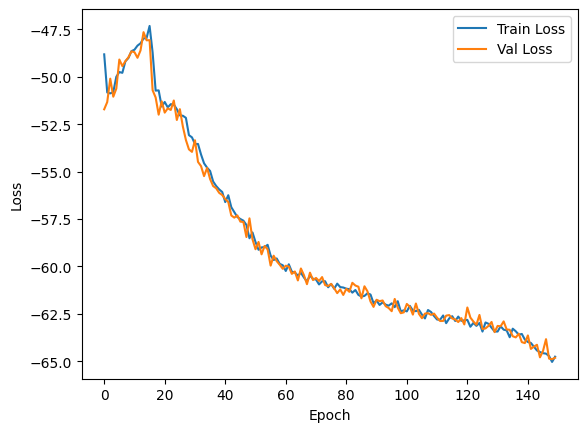

In [22]:


history = train_model(model=model, train_loader=train_loader, val_loader=val_loader,epochs=150,batch_size=32,lr=5e-4,kl_anneal_epochs=30, patience=50,device="cuda")

plt.plot(history['train'], label="Train Loss")
plt.plot(history['val'], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Contenu du JSON :
{'train': [-48.81196746929876, -50.822088455509494, -50.872511903230134, -50.801630633586164, -49.99591803679595, -49.74551280983934, -49.78657275534965, -49.18025391209233, -49.005712399182016, -48.644550115997724, -48.56798174574568, -48.3531848117038, -48.23143746659562, -47.97416415730038, -47.95565305916039, -47.31265102206049, -48.7170825374019, -50.725530712454166, -50.71316586056271, -51.56479885255968, -51.324081498223386, -51.60913098180616, -51.44110379949346, -51.463380110800806, -51.706148209442965, -52.03287322456772, -52.05307113200694, -52.16195158442935, -53.07436075983821, -53.190248096740994, -53.54282188415527, -53.54038961513622, -54.09474070007737, -54.56133412026071, -54.7925500869751, -54.96633847984108, -55.52044604275678, -55.75675863833041, -55.936404756597575, -56.07297518446638, -56.606429886173565, -56.24384575921137, -56.8769469905544, -57.13967900662809, -57.3964267550288, -57.49974017529873, -57.58580598315677, -57.81217392070874, -58.

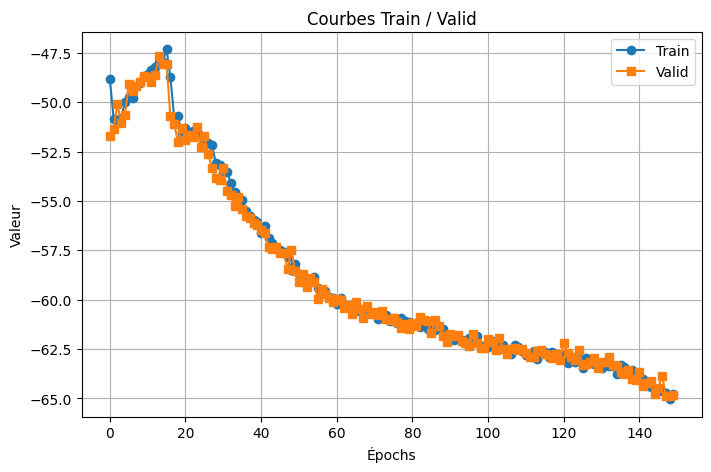

In [23]:
# Chemin vers le fichier JSON (ex: dossier "data")
chemin_fichier = os.path.join("checkpoints", "history.json")

def lire_json(chemin):
    try:
        with open(chemin, "r", encoding="utf-8") as fichier:
            contenu = json.load(fichier)
            return contenu
    except FileNotFoundError:
        print(f"Fichier introuvable : {chemin}")
    except json.JSONDecodeError:
        print("Erreur : le fichier n'est pas un JSON valide.")

# Lecture du contenu
data = lire_json(chemin_fichier)

if data:
    print("Contenu du JSON :")
    print(data)


train = data.get("train")
valid = data.get("val")

# Vérification
if train is None or valid is None:
    raise ValueError("Le fichier JSON doit contenir les clés 'train' et 'valid'")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(train, label="Train", marker="o")
plt.plot(valid, label="Valid", marker="s")

plt.title("Courbes Train / Valid")
plt.xlabel("Épochs")
plt.ylabel("Valeur")
plt.grid(True)
plt.legend()

plt.show()


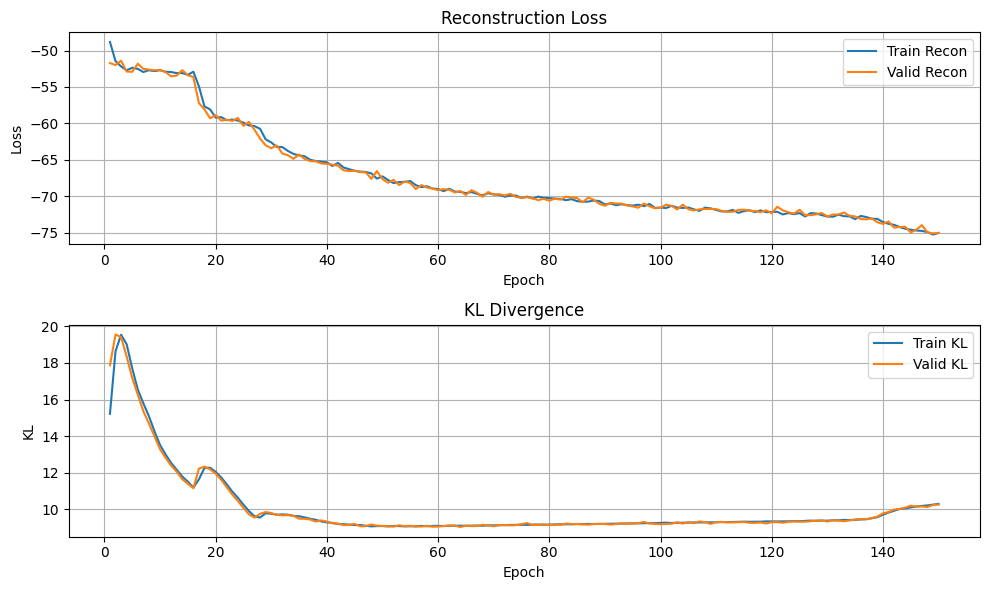

In [24]:
# Charger l'historique
with open("checkpoints/history.json", "r") as f:
    history = json.load(f)

train_recon = history["train_recon"]
train_kld = history["train_kld"]
val_recon = history["val_recon"]
val_kld = history["val_kld"]

epochs = range(1, len(train_recon) + 1)

plt.figure(figsize=(10, 6))

# Reconstruction
plt.subplot(2, 1, 1)
plt.plot(epochs, train_recon, label="Train Recon")
plt.plot(epochs, val_recon, label="Valid Recon")
plt.title("Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# KL Divergence
plt.subplot(2, 1, 2)
plt.plot(epochs, train_kld, label="Train KL")
plt.plot(epochs, val_kld, label="Valid KL")
plt.title("KL Divergence")
plt.xlabel("Epoch")
plt.ylabel("KL")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


The function below is a modified version of the training function of the dataset, in which we added a scheduler for the learning rate, which reduces the learning rate when the validation curve becomes flat. 

In [25]:
#### modifications ajout scheduler learning rate
import os
import json
import torch
from tqdm import tqdm

def save_checkpoint(state, checkpoint_dir, name="last.pt"):
    os.makedirs(checkpoint_dir, exist_ok=True)
    path = os.path.join(checkpoint_dir, name)
    torch.save(state, path)

# MODIFICATION 1 : Ajout de l'argument 'scheduler' pour recharger son état
def load_checkpoint(model, optimizer, scheduler, checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    
    # On charge l'état du scheduler s'il existe dans la sauvegarde
    if "scheduler_state" in checkpoint and scheduler is not None:
        scheduler.load_state_dict(checkpoint["scheduler_state"])
        
    start_epoch = checkpoint["epoch"] + 1
    history = checkpoint["history"]
    print(f"Checkpoint loaded from: {checkpoint_path}")
    return start_epoch, history

def train_model_with_scheduler(
    model,
    train_loader,
    val_loader,
    checkpoint_dir="checkpoints",
    resume=False,
    epochs=50,
    batch_size=32,
    lr=1e-4,
    kl_anneal_epochs=10,
    patience=20, 
    device="cuda"
):

    device = torch.device(device if torch.cuda.is_available() else "cpu")
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # MODIFICATION 2 : Initialisation du Scheduler
    # factor=0.5 : Divise le learning rate par 2 quand ça stagne
    # patience=5 : Attend 5 epochs de stagnation avant d'agir
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    # Tracking
    history = {
        "train": [], "val": [], "beta": [],
        "train_recon": [], "train_kld": [],
        "val_recon": [], "val_kld": [],
        "lr": [] # MODIFICATION : On garde une trace du Learning Rate
    }

    start_epoch = 0
    best_val_loss = float("inf")
    patience_counter = 0

    # Resume training
    last_ckpt = os.path.join(checkpoint_dir, "last.pt")
    if resume and os.path.exists(last_ckpt):
        # MODIFICATION : On passe le scheduler à la fonction de chargement
        start_epoch, history = load_checkpoint(model, optimizer, scheduler, last_ckpt, device)
        print(f"Resuming from epoch {start_epoch}")

    # Training loop
    for epoch in range(start_epoch, epochs):
        model.train()
        total_recon, total_kld = 0, 0
        n_batches = 0

        # Calcul de Beta (KL Annealing)
        beta = min(1.0, epoch / kl_anneal_epochs) if kl_anneal_epochs > 0 else 1.0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training"):
            batch = batch.to(device)             
            batch = batch.permute(1, 0, 2)       
            seq_len, batch_size, _ = batch.shape

            optimizer.zero_grad()
            _,recon, kld = model(batch)

            recon = recon / (batch_size * seq_len)
            kld = kld / (batch_size * seq_len)
            loss = recon + beta * kld

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_recon += recon.item()
            total_kld += kld.item()
            n_batches += 1

        train_recon = total_recon / n_batches
        train_kld = total_kld / n_batches
        train_loss = train_recon + beta * train_kld

        # Validation
        val_recon, val_kld = evaluate(model, val_loader, device=device)
        val_loss = val_recon + beta * val_kld

        # MODIFICATION 3 : Step du Scheduler
        # On informe le scheduler de la nouvelle validation loss
        scheduler.step(val_loss)
        
        # Récupération du LR actuel pour l'affichage
        current_lr = optimizer.param_groups[0]['lr']

        print(f"[{epoch+1}/{epochs}] "
              f"Train: {train_loss:.3f} | Val: {val_loss:.3f} | "
              f"β={beta:.3f} | LR={current_lr:.2e}")

        # Update history
        history["train"].append(train_loss)
        history["val"].append(val_loss)
        history["beta"].append(beta)
        history["train_recon"].append(train_recon)
        history["train_kld"].append(train_kld)
        history["val_recon"].append(val_recon)
        history["val_kld"].append(val_kld)
        history["lr"].append(current_lr) # On loggue le LR

        # Save Checkpoint Dict (Helper)
        # MODIFICATION 4 : On ajoute l'état du scheduler dans la sauvegarde
        checkpoint_dict = {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(), # <--- ICI
            "history": history
        }

        # Save last checkpoint
        save_checkpoint(checkpoint_dict, checkpoint_dir, "last.pt")

        # Save best model
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            save_checkpoint(checkpoint_dict, checkpoint_dir, "best.pt")
            patience_counter = 0
            print(" → Saved BEST model")
        else:
            patience_counter += 1

        # Early stopping
        if patience_counter >= patience:
            print(f"Early stopping triggered after {patience} epochs without improvement.")
            break

    # Save history as JSON
    with open(os.path.join(checkpoint_dir, "history.json"), "w") as f:
        # Helper pour rendre les float32 sérialisables en JSON si besoin
        class FloatEncoder(json.JSONEncoder):
            def default(self, obj):
                if isinstance(obj, torch.Tensor): return obj.item()
                return json.JSONEncoder.default(self, obj)
        json.dump(history, f, indent=4, cls=FloatEncoder)

    print("\nTraining complete.")
    return history

Epoch 1/200 Training: 100%|██████████| 74/74 [00:04<00:00, 18.18it/s]


[1/200] Train: 0.189 | Val: -20.394 | β=0.000 | LR=1.00e-03
 → Saved BEST model


Epoch 2/200 Training: 100%|██████████| 74/74 [00:04<00:00, 17.60it/s]


[2/200] Train: -23.679 | Val: -24.340 | β=0.033 | LR=1.00e-03
 → Saved BEST model


Epoch 3/200 Training: 100%|██████████| 74/74 [00:04<00:00, 18.36it/s]


...

[198/200] Train: -64.829 | Val: -64.735 | β=1.000 | LR=5.00e-04


Epoch 199/200 Training: 100%|██████████| 74/74 [00:06<00:00, 10.99it/s]


[199/200] Train: -65.027 | Val: -65.482 | β=1.000 | LR=5.00e-04


Epoch 200/200 Training: 100%|██████████| 74/74 [00:07<00:00,  9.51it/s]


[200/200] Train: -64.720 | Val: -64.503 | β=1.000 | LR=5.00e-04

Training complete.


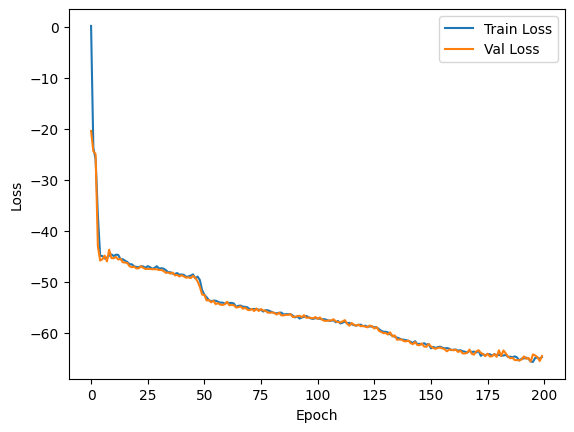

In [26]:
model_2 = SRNN(x_dim=80).to(device)

history = train_model_with_scheduler(model=model_2, 
                                     train_loader=train_loader, 
                                     val_loader=val_loader,
                                     epochs=200,
                                     batch_size=32,
                                     lr=1e-3,
                                     kl_anneal_epochs=30, 
                                     patience=50,
                                     device="cuda")

plt.plot(history['train'], label="Train Loss")
plt.plot(history['val'], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Contenu du JSON :
{'train': [0.18932604125222643, -23.679100797412634, -25.92335373904254, -36.87032571096678, -44.85930314622484, -44.91350920995076, -45.39766850858121, -45.21174163646526, -44.82170715675698, -44.58321906553733, -44.907478366886174, -44.641007261018494, -44.693061447143556, -45.550366928770735, -45.538751208674796, -45.828917509800675, -46.088820844083216, -46.52279110255542, -46.52921769941176, -46.93648019137683, -47.04986129365526, -47.07972552003087, -46.931052659008955, -46.942478114849806, -47.2234409899325, -46.89482289284199, -47.1006864156809, -47.401666669587826, -47.24969961492865, -46.90667580076166, -47.3727761668128, -47.29979134894706, -47.37934490796682, -47.6768236675778, -48.074565739245024, -48.07878844802444, -48.36932158470154, -48.42837909750036, -48.247714081326045, -48.58698960897085, -48.51186549985731, -48.614449513925095, -49.0036053270907, -48.900925275441764, -48.73700972505518, -48.50966720323305, -49.27937044968476, -48.93530770894644, 

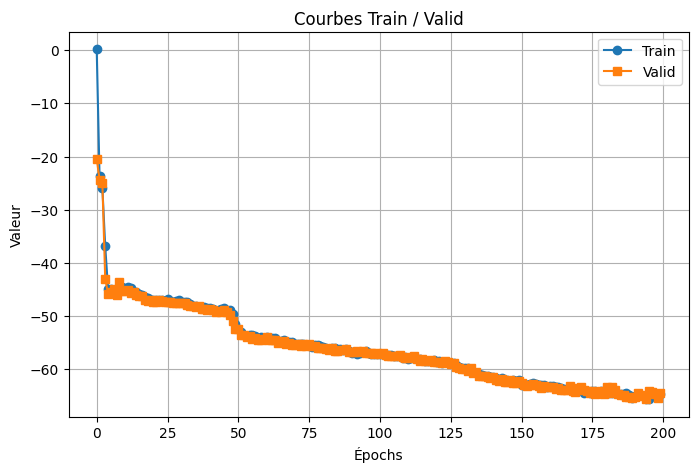

In [27]:
# Chemin vers le fichier JSON (ex: dossier "data")
chemin_fichier = os.path.join("checkpoints", "history.json")

def lire_json(chemin):
    try:
        with open(chemin, "r", encoding="utf-8") as fichier:
            contenu = json.load(fichier)
            return contenu
    except FileNotFoundError:
        print(f"Fichier introuvable : {chemin}")
    except json.JSONDecodeError:
        print("Erreur : le fichier n'est pas un JSON valide.")

# Lecture du contenu
data = lire_json(chemin_fichier)

if data:
    print("Contenu du JSON :")
    print(data)


train = data.get("train")
valid = data.get("val")

# Vérification
if train is None or valid is None:
    raise ValueError("Le fichier JSON doit contenir les clés 'train' et 'valid'")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(train, label="Train", marker="o")
plt.plot(valid, label="Valid", marker="s")

plt.title("Courbes Train / Valid")
plt.xlabel("Épochs")
plt.ylabel("Valeur")
plt.grid(True)
plt.legend()

plt.show()


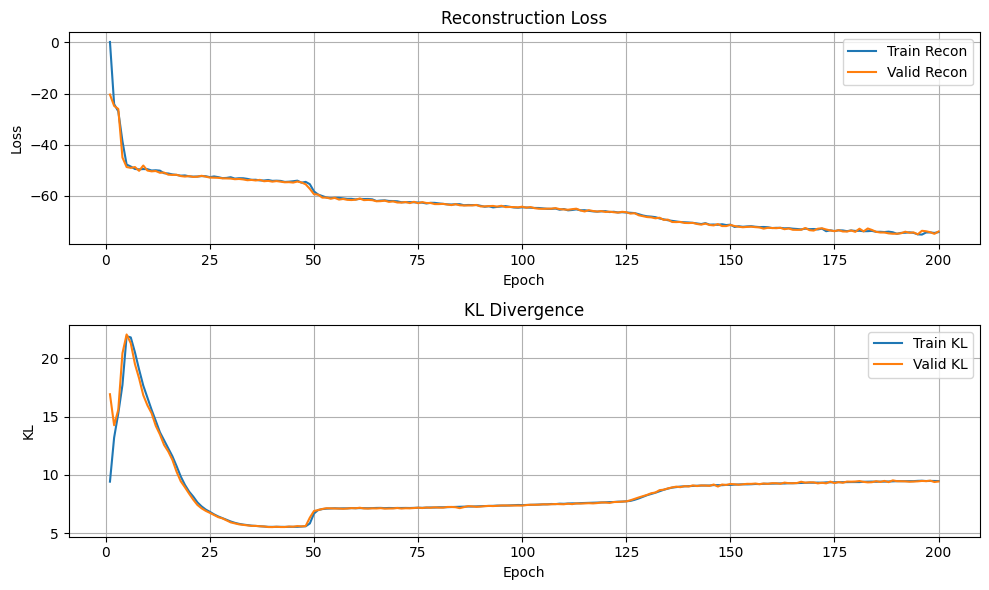

In [28]:
# Charger l'historique
with open("checkpoints/history.json", "r") as f:
    history = json.load(f)

train_recon = history["train_recon"]
train_kld = history["train_kld"]
val_recon = history["val_recon"]
val_kld = history["val_kld"]

epochs = range(1, len(train_recon) + 1)

plt.figure(figsize=(10, 6))

# Reconstruction
plt.subplot(2, 1, 1)
plt.plot(epochs, train_recon, label="Train Recon")
plt.plot(epochs, val_recon, label="Valid Recon")
plt.title("Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# KL Divergence
plt.subplot(2, 1, 2)
plt.plot(epochs, train_kld, label="Train KL")
plt.plot(epochs, val_kld, label="Valid KL")
plt.title("KL Divergence")
plt.xlabel("Epoch")
plt.ylabel("KL")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# Reconstruction of audios

In [29]:
# !git checkout main

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SRNN(x_dim=80).to(device)

# 2. Définir le chemin vers le checkpoint
checkpoint_path = "checkpoints/best.pt"  

if not os.path.exists(checkpoint_path):
    print("Attention: 'best.pt' introuvable, essai avec 'last.pt'...")
    checkpoint_path = "checkpoints/last.pt"

# 3. Charger les poids
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    
    epoch_saved = checkpoint["epoch"]

    # Mettre en mode évaluation (bloque le Dropout, etc.)
    model.eval()
else:
    print("Aucun checkpoint trouvé.")

In [32]:
import librosa
import soundfile as sf
import IPython.display as ipd
import numpy as np

# --- CONFIGURATION ---
IDX_TO_TEST = 0  # Changez ce chiffre pour tester d'autres samples
STATS_PATH = "mel_stats.pt"

# 1. Charger les stats pour la dénormalisation
stats = torch.load(STATS_PATH)
# On gère le cas où stats serait sur GPU ou CPU
mean_val = stats["mean"].to('cpu')
std_val = stats["std"].to('cpu')


# 2. Récupérer l'input (Original)
# On prend un sample du dataset
data_item = full_dataset[IDX_TO_TEST]
original_mel = data_item

# 3. Passer dans le modèle (Reconstruction)
# Le modèle attend (Seq, Batch, Feat). Notre sample est (Seq, Feat).
# On ajoute la dimension batch avec unsqueeze(1)
input_tensor = original_mel.unsqueeze(1).to(device) # -> (200, 1, 80)

with torch.no_grad():
    recon_mel, _, _ = model(input_tensor) # Le modèle renvoie (recon, kld)

# On affiche la shape pour comprendre (optionnel, pour debug)
print(f"Shape sortie modèle : {recon_mel.shape}")

# Au lieu de forcer squeeze(1), on s'adapte :
# Si la shape est (200, 1, 80) -> squeeze(1) marche -> devient (200, 80)
# Si la shape est (200, 80)    -> Pas besoin de squeeze
# Si la shape est (1, 200, 80) -> squeeze(0) serait nécessaire

if recon_mel.dim() == 3 and recon_mel.shape[1] == 1:
    recon_mel = recon_mel.squeeze(1) # Cas attendu (Seq, 1, Feat) -> (Seq, Feat)
elif recon_mel.dim() == 3 and recon_mel.shape[0] == 1:
    recon_mel = recon_mel.squeeze(0) # Cas alternatif (1, Seq, Feat) -> (Seq, Feat)
original_mel = original_mel.cpu()

# 4. Fonction Helper : Mel -> Audio
def mel_to_audio_playable(mel_tensor, mean, std, name):

    # On force tout le monde sur le CPU pour éviter le crash
    mel_tensor = mel_tensor.detach().cpu()
    
    # A. Dénormalisation
    mel_denorm = mel_tensor * (std + 1e-6) + mean
    
    # B. Conversion Numpy & Transpose (Seq, Feat) -> (Feat, Seq)
    mel_numpy = mel_denorm.numpy().T
    
    # C. dB to Power
    mel_power = librosa.db_to_power(mel_numpy)
    
    # D. Griffin-Lim
    audio = librosa.feature.inverse.mel_to_audio(
        mel_power, sr=22050, n_fft=1024, hop_length=256, win_length=1024
    )
    
    # E. Sauvegarde et Affichage
    filename = f"{name}.wav"
    sf.write(filename, audio, 22050)
    print(f" {name} :")
    display(ipd.Audio(filename))

# 5. Lancer la comparaison
print(f"--- TEST SUR LE SAMPLE {IDX_TO_TEST} ---")
# Afficher le nom du fichier d'origine si possible
try:
    print(f"Fichier source : {get_real_filename(full_dataset, IDX_TO_TEST)}")
except:
    pass

mel_to_audio_playable(original_mel, mean_val, std_val, "1_Original_Input")
mel_to_audio_playable(recon_mel, mean_val, std_val, "2_Reconstructed_Output")

Shape sortie modèle : torch.Size([200, 1, 80])
--- TEST SUR LE SAMPLE 0 ---
 1_Original_Input :


 2_Reconstructed_Output :


## Reconstruction mel to wav

La classe utilisée initialement pour passer de wav à mel. Nécessaire pour réaccéder aux statistiques.

In [33]:
# import os
# import torch
# import soundfile as sf
# import torchaudio
# from torchaudio.transforms import MelSpectrogram, AmplitudeToDB
# import torch.nn.functional as F
# import numpy as np

# # -----------------------
# # DATASET PYTORCH WAV SANS TORCHAUDIO.LOAD
# # -----------------------
# class MelDataset(torch.utils.data.Dataset):
#     def __init__(self, root, segment_frames=200, sample_rate=22050, n_mels=80):
#         self.root = root
#         self.segment_frames = segment_frames
#         self.sample_rate = sample_rate
        
#         self.mel = MelSpectrogram(
#             sample_rate=sample_rate,
#             n_fft=1024,
#             hop_length=256,
#             win_length=1024,
#             n_mels=n_mels
#         )
#         self.db = AmplitudeToDB()

#         # lister tous les fichiers wav
#         self.wav_files = []
#         for subfolder in os.listdir(root):
#             sub_path = os.path.join(root, subfolder)
#             if os.path.isdir(sub_path):
#                 for f in os.listdir(sub_path):
#                     if f.endswith(".wav"):
#                         self.wav_files.append(os.path.join(sub_path, f))

#         if len(self.wav_files) == 0:
#             raise RuntimeError("Aucun fichier .wav trouvé dans root.")

#         self._compute_statistics()

#     # -----------------------
#     # CHARGEMENT AUDIO AVEC SOUNDFILE
#     # -----------------------
#     def _load_wav(self, path):
#         wav, sr = sf.read(path)            # -> numpy array (N,) ou (N,2)
#         if wav.ndim == 2:                  # stereo → mono
#             wav = wav.mean(axis=1)
#         wav = wav.astype(np.float32)
        
#         # conversion tensor
#         wav = torch.tensor(wav).unsqueeze(0)  # (1,N)

#         # resample si nécessaire
#         if sr != self.sample_rate:
#             wav = torchaudio.functional.resample(wav, sr, self.sample_rate)

#         # normalisation amplitude
#         wav = wav / wav.abs().max()

#         return wav

#     # conversion en melspec
#     def _wav_to_mel(self, wav):
#         mel = self.mel(wav)
#         mel_db = self.db(mel)
#         return mel_db.squeeze(0).transpose(0, 1)  # (frames, mels)

#     # calcul mean/std global
#     def _compute_statistics(self):
#         print("Calcul des statistiques globales...")
#         mel_list = []
#         for path in self.wav_files:
#             wav = self._load_wav(path)
#             mel = self._wav_to_mel(wav)
#             mel_list.append(mel)

#         all_mels = torch.cat(mel_list, dim=0)
#         self.mean = all_mels.mean(dim=0)
#         self.std = all_mels.std(dim=0)
#         print("done.")

#     def __len__(self):
#         return len(self.wav_files)

#     def __getitem__(self, idx):
#         wav = self._load_wav(self.wav_files[idx])
#         mel = self._wav_to_mel(wav)

#         mel = (mel - self.mean) / (self.std + 1e-6)

#         if mel.shape[0] < self.segment_frames:
#             pad = self.segment_frames - mel.shape[0]
#             mel = F.pad(mel, (0, 0, 0, pad))

#         max_start = mel.shape[0] - self.segment_frames
#         start = torch.randint(0, max_start + 1, (1,)).item()
#         return mel[start:start + self.segment_frames]

In [34]:
# dataset = MelDataset(
#     root = "/home/onyxia/work/Dynamical-Variational-Autoencoders/data/data_wav",
#     segment_frames=200,
#     sample_rate=22050,
#     n_mels=80
# )

In [35]:
# print("Type des stats :", type(dataset.mean))
# print(f"Forme (Shape) : {dataset.mean.shape}") 

# print(f"Moyenne globale approx (dB) : {dataset.mean.mean().item():.2f}")
# print(f"Ecart-type global approx : {dataset.std.mean().item():.2f}")


# torch.save({
#     "mean": dataset.mean, 
#     "std": dataset.std
# }, "mel_stats.pt")

In [36]:
#fonction pour voir le 1er fichier qu'on a dans le dataset

def get_real_filename(dataset, target_idx):
    # 1. Cas : C'est un Subset (issu de random_split)
    if isinstance(dataset, torch.utils.data.Subset):
        real_idx = dataset.indices[target_idx]
        return get_real_filename(dataset.dataset, real_idx)

    # 2. Cas : C'est un ConcatDataset
    elif isinstance(dataset, torch.utils.data.ConcatDataset):
        current_idx = target_idx
        for sub_d in dataset.datasets:
            if current_idx < len(sub_d):
                return get_real_filename(sub_d, current_idx)
            current_idx -= len(sub_d)
            
    # 3. Cas final : C'est votre AudioDataset
    else:
        # On essaie plusieurs noms potentiels de variables
        potential_names = ['wav_files', 'files', 'paths', 'audio_files', 'data', 'file_paths']
        
        for name in potential_names:
            if hasattr(dataset, name):
                # On a trouvé le bon nom !
                return getattr(dataset, name)[target_idx]
        
        # Si on arrive ici, c'est qu'on n'a pas trouvé la variable
        print(f"ERREUR: Impossible de trouver la liste des fichiers dans {type(dataset)}")
        print(f"Les attributs disponibles sont : {list(dataset.__dict__.keys())}")
        return "Nom de variable introuvable"

# --- Test ---
filename = get_real_filename(full_dataset, 0)
print("Fichier audio correspondant :", filename)

Fichier audio correspondant : ../data/mels_saved/part_0/mel_782.pt


In [37]:
import librosa
import soundfile as sf
import IPython.display as ipd

# On accède directement à l'index 0 du dataset
data_item = full_dataset[1]


if isinstance(data_item, tuple) or isinstance(data_item, list):
    mel_tensor = data_item[0] 
else:
    mel_tensor = data_item  

# ---------------------------------------------------------
# 2. CHARGER LES STATS
# ---------------------------------------------------------

stats = torch.load("mel_stats.pt")
mean_val = stats["mean"]
std_val = stats["std"]
print(mean_val,std_val)

# ---------------------------------------------------------
# 3. DÉNORMALISATION & CONVERSION
# ---------------------------------------------------------

# Dénormalisation
mel_denorm = mel_tensor * (std_val + 1e-6) + mean_val

# Passage en Numpy
mel_numpy = mel_denorm.detach().cpu().numpy()

# Librosa veut (Frequence, Temps).
if mel_numpy.shape[0] > mel_numpy.shape[1]: 
    mel_numpy = mel_numpy.T

# Inversion DB -> Power
mel_power = librosa.db_to_power(mel_numpy)

# ---------------------------------------------------------
# 4. RECONSTRUCTION (Griffin-Lim)
# ---------------------------------------------------------
audio_reconstruit = librosa.feature.inverse.mel_to_audio(
    mel_power,
    sr=22050,
    n_fft=1024,
    hop_length=256,
    win_length=1024
)

# ---------------------------------------------------------
# 5. ÉCOUTE
# ---------------------------------------------------------
sf.write('test_direct_0.wav', audio_reconstruit, 22050)
print(f"Vous écoutez le fichier : {get_real_filename(full_dataset, 1)}")
ipd.Audio('test_direct_0.wav')

tensor([  7.0757,   3.8944,   2.2081,   0.2902,  -1.5965,  -3.5759,  -2.0763,
         -4.5851,  -6.4180,  -8.2152,  -7.4840,  -6.6061,  -6.4498,  -6.9864,
         -7.3140,  -7.6709,  -8.8572, -10.8677, -12.8451, -13.8795, -14.4383,
        -14.9951, -15.0271, -15.0509, -15.0764, -15.4025, -15.6771, -16.1204,
        -16.6914, -16.8782, -16.8570, -16.9449, -16.7907, -17.0086, -17.0430,
        -17.1980, -17.1161, -17.2472, -17.5169, -18.0103, -18.2753, -18.4062,
        -18.4982, -18.6858, -18.8361, -18.8374, -18.6412, -18.5162, -18.5097,
        -18.5340, -18.7379, -19.0507, -19.5742, -20.3211, -20.8152, -21.2400,
        -21.9248, -22.5229, -23.1291, -23.9064, -24.7903, -25.5190, -26.1762,
        -26.5336, -26.7076, -26.6969, -26.5931, -26.5081, -26.1831, -26.0359,
        -26.2120, -26.0530, -25.6426, -25.7089, -26.1805, -26.7168, -26.8908,
        -27.1745, -27.6241, -28.1636]) tensor([ 6.4362,  7.0244,  9.8288, 13.7338, 16.6195, 20.0949, 22.9003, 23.1618,
        21.7860, 20.474

# Generation

In [38]:
import librosa
import numpy as np

In [39]:
import torch
import numpy as np
import torchaudio
from torchaudio.transforms import InverseMelScale
from IPython.display import Audio, display


@torch.no_grad()
def generate_and_listen_vrnn_mel(
    vrnn,
    ckpt_path,
    mean,
    std,
    seq_len,
    device="cpu",
    deterministic=False,
    sample_rate=22050,
    n_fft=1024,
    hop_length=256,
    win_length=1024,
    n_mels=80,
    griffin_lim_iters=32
):
    """
    Génère un audio depuis un VRNN entraîné sur mel-spectrogrammes normalisés
    """

    # ---------- Load checkpoint
    ckpt = torch.load(ckpt_path, map_location=device)
    if "model_state" in ckpt:
        vrnn.load_state_dict(ckpt["model_state"])
    else:
        vrnn.load_state_dict(ckpt)

    vrnn.to(device)
    vrnn.eval()

    # ---------- Safety checks
    assert vrnn.x_dim == n_mels, "x_dim ≠ n_mels"
    assert mean.shape[0] == n_mels
    assert std.shape[0] == n_mels

    # ---------- Generate normalized mel
    mel_norm = vrnn.generate(
        seq_len=seq_len,
        batch=1,
        device=device,
        deterministic=deterministic
    )

    mel_norm = mel_norm.squeeze(1).T  # (80, T)

    # ---------- De-normalize
    mean = mean.to(device).unsqueeze(1)
    std = std.to(device).unsqueeze(1)

    mel_db = mel_norm * std + mean

    # ---------- DB → amplitude
    mel = torch.pow(10.0, mel_db / 10.0)

    # ---------- Mel → STFT magnitude
    inv_mel = InverseMelScale(
        n_stft=n_fft // 2 + 1,
        n_mels=n_mels,
        sample_rate=sample_rate
    ).to(device)

    stft_mag = inv_mel(mel)

    # ---------- Griffin-Lim
    waveform = torchaudio.functional.griffinlim(
        stft_mag,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=win_length,
        power=1.0,
        n_iter=griffin_lim_iters
    )

    # ---------- Normalize
    waveform = waveform / (waveform.abs().max() + 1e-8)

    audio = waveform.squeeze().cpu().numpy()

    # ---------- Play
    display(Audio(audio, rate=sample_rate))

    return audio


In [40]:
def generate_and_listen_vrnn_mel(vrnn, ckpt_path, mean, std, seq_len=400,
                                 deterministic=False, device="cpu",
                                 n_fft=1024, hop_length=256, win_length=1024,
                                 n_iter=32, sample_rate=22050):
    """
    Génère un audio depuis un VRNN entraîné sur mel-spectrogrammes normalisés.
    Retourne un waveform torch.Tensor sur CPU.
    """
    # ----- Charger le checkpoint -----


    # ----- Génération du spectrogramme -----
    with torch.no_grad():
        mel = vrnn.generate(seq_len=seq_len, device=device, deterministic=deterministic).to(device)
        mel = mel * std + mean  # dénormalisation

    # ----- Inverse Mel → STFT -----
    inv_mel = torchaudio.transforms.InverseMelScale(
        n_stft=(n_fft // 2 + 1),
        n_mels=mel.shape[1],
        sample_rate=sample_rate
    )
    stft_mag = inv_mel(mel.T)  # shape: [freq, time]

    # ----- Redimension pour éviter le padding Griffin-Lim -----
    # expected_time = stft_mag.shape[1]
    # if expected_time < n_fft:
    #     stft_mag = F.pad(stft_mag, (0, n_fft - expected_time))

    # # # ----- Griffin-Lim -----
    # window = torch.hann_window(win_length).to(device)
    # waveform_length = stft_mag.shape[1] * hop_length

    # waveform = torchaudio.functional.griffinlim(
    #     specgram=stft_mag,
    #     n_fft=n_fft,
    #     hop_length=hop_length,
    #     win_length=win_length,
    #     window=window,
    #     power=1.0,
    #     n_iter=n_iter,
    #     momentum=0.99,
    #     length=waveform_length,
    #     rand_init=True
    # )

    # # ----- Normalisation finale -----
    # waveform = waveform / (waveform.abs().max() + 1e-8)

    # return waveform.cpu()

    return mel

In [41]:

import torch.nn.functional as F

In [46]:
vrnn = SRNN(
    x_dim=80,
)

stats = torch.load("mel_stats.pt", map_location="cpu")

mean = stats["mean"]
std = stats["std"]

mel = generate_and_listen_vrnn_mel(
    vrnn=vrnn,
    ckpt_path="checkpoints/best.pt",
    mean=mean,
    std=std,
    seq_len=400,        # ≈ 400 frames
    deterministic=False,
    device="cpu"
)


/tmp/ipykernel_8458/1136968250.py:23: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4416.)
  stft_mag = inv_mel(mel.T)  # shape: [freq, time]


In [47]:
import matplotlib.pyplot as plt

def plot_mel(mel, title="Mel spectrogram"):
    """
    mel: (T, 80) ou (80, T)
    """
    mel_2d = np.squeeze(mel)  # shape becomes (80, 400)

    plt.figure(figsize=(10, 4))
    plt.imshow(mel_2d, aspect="auto", origin="lower")
    plt.colorbar()
    plt.title("Mel Spectrogram")
    plt.show()


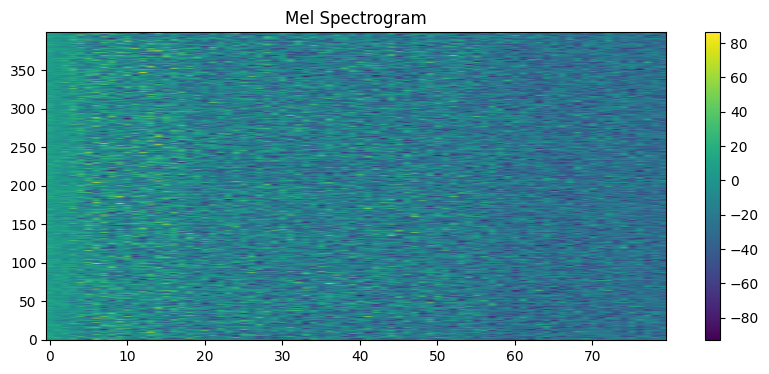

In [48]:
plot_mel(mel)

In [49]:
def compare_stats(mel_real, mel_gen):
    print("REAL  mean:", mel_real.mean().item(), "std:", mel_real.std().item())
    print("GEN   mean:", mel_gen.mean().item(), "std:", mel_gen.std().item())


In [50]:
def temporal_diff_energy(mel):
    diff = mel[1:] - mel[:-1]
    return diff.abs().mean().item()

print("REAL temporal diff:", temporal_diff_energy(mel_real))
print("GEN  temporal diff:", temporal_diff_energy(mel_gen))


NameError: name 'mel_real' is not defined